# 04 — Algoritmo Genético (Genetic Algorithm)
**Metaheurísticas — Notebook 4 de 5**

Los Algoritmos Genéticos (John **Holland, 1975**) son metaheurísticas **poblacionales**
inspiradas en la selección natural. Mantienen una *población* de soluciones que
evolucionan mediante **selección**, **cruce** y **mutación**. Las más aptas se
reproducen más, propagando buenos rasgos.

## ¿Qué aprenderás?
1. Vocabulario: *cromosoma, fitness, selección, cruce, mutación, elitismo*.
2. Exploración vs. **explotación** y cómo los operadores los controlan.
3. Motor genérico reutilizable.
4. Aplicaciones:
   - **Ejemplo 1 — Coloración de Grafos** (20 nodos).
   - **Ejemplo 2 — Función de Ackley** (optimización continua, 2D).
5. Convergencia prematura y cómo evitarla.


## 1. El bucle evolutivo

```
funcion AlgoritmoGenetico(tam_pop, n_gen):
    poblacion <- individuos aleatorios
    evaluar fitness de cada individuo
    repetir n_gen veces:
        elites <- copiar los mejores individuos    <- elitismo
        mientras siguiente generacion no llena:
            padre1, padre2 <- seleccion(poblacion)
            hijo1, hijo2   <- cruce(padre1, padre2)
            hijo1, hijo2   <- mutacion(hijo1), mutacion(hijo2)
            agregar hijos
        poblacion <- elites + hijos
        evaluar fitness
    retornar mejor individuo de la historia
```

## 2. Los cuatro operadores

| Operador | Rol | Controla |
|---|---|---|
| **Selección** | Presión hacia buenas soluciones | Explotación |
| **Cruce** | Combinar partes de dos padres | Explotación |
| **Mutación** | Cambio aleatorio pequeño | Exploración |
| **Elitismo** | Los mejores pasan sin cambios | Garantía de no retroceso |

## 3. Conceptos clave

### Cromosoma y codificación
El **cromosoma** representa una solución. Para coloración: vector entero $[c_0, \ldots, c_{n-1}]$
donde $c_v$ es el color del nodo $v$. El problema de **simetría** (color 0 y 1 son
intercambiables) se maneja penalizando conflictos en la función de fitness.

### Selección por torneo
Elegir $k$ individuos al azar; el más apto se convierte en padre. No requiere fitness
proporcional (evita el efecto "gallina gorda" de la ruleta). El tamaño $k$ controla
la **presión de selección**: $k$ grande $\to$ más greedy $\to$ más explotación.

### Hipótesis de los bloques de construcción
Buenos sub-vectores de genes ("bloques") contribuyen al fitness. El cruce puede
combinar dos padres con buenos bloques distintos para crear un hijo con ambos.
Funciona mejor cuando el fitness es separable y los bloques son cortos.


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("common.py")))
import numpy as np
import matplotlib.pyplot as plt
import common

G = common.crear_grafo(n=20, prob=0.35, seed=42)
pos = common.posiciones_grafo(G, seed=42)
n = G.number_of_nodes()

s_greedy = common.coloracion_greedy(G, seed=0)
K_MAX = common.num_colores(s_greedy) + 1   # colores disponibles con margen
print(f"Grafo: {n} nodos, {G.number_of_edges()} aristas")
print(f"Greedy: {common.num_colores(s_greedy)} colores -> K_MAX = {K_MAX}")


Grafo: 20 nodos, 76 aristas
Greedy: 5 colores -> K_MAX = 6


In [2]:
def seleccion_torneo(pop, fits, k=3):
    """Torneo: elegir k individuos al azar, retornar copia del mas apto."""
    idx = np.random.choice(len(pop), size=k, replace=False)
    ganador = idx[np.argmax([fits[i] for i in idx])]
    return pop[ganador].copy()

def cruce_uniforme(p1, p2):
    """
    Cruce uniforme: cada gen del hijo1 viene de p1 con prob 0.5, de p2 si no.
    hijo2 recibe los genes complementarios.
    Adecuado para representaciones enteras (colores).
    """
    mascara = np.random.random(len(p1)) < 0.5
    h1 = np.where(mascara, p1, p2)
    h2 = np.where(mascara, p2, p1)
    return h1, h2

def mutacion_color(ind, k_max, tasa=0.1):
    """
    Mutacion: con probabilidad tasa por gen, asignar un color aleatorio.
    Permite explorar colores completamente distintos para un nodo.
    """
    ind = ind.copy()
    mask = np.random.random(len(ind)) < tasa
    ind[mask] = np.random.randint(0, k_max, size=int(mask.sum()))
    return ind

def algoritmo_genetico(G, K, tam_pop=80, n_gen=200, tasa_cruce=0.85,
                       tasa_mut=0.08, elitismo=3, k_torneo=3, seed=0):
    """
    AG para Coloracion de Grafos.
    Fitness = -costo (minimizamos costo, maximizamos fitness).
    K: numero de colores disponibles.
    """
    np.random.seed(seed)
    n_local = G.number_of_nodes()
    fitness_fn = lambda ind: -common.costo(list(ind), G)

    # Poblacion inicial: 1 greedy + resto aleatorio
    s_init = np.array(common.coloracion_greedy(G, seed=0))
    pop = [s_init.copy()] + [np.random.randint(0, K, size=n_local)
                              for _ in range(tam_pop - 1)]
    fits = [fitness_fn(ind) for ind in pop]
    mejor = pop[np.argmax(fits)].copy()
    mejor_fit = max(fits)
    historia = [-mejor_fit]

    for _gen in range(n_gen):
        orden = np.argsort(fits)[::-1]
        nueva = [pop[orden[i]].copy() for i in range(elitismo)]

        while len(nueva) < tam_pop:
            p1 = seleccion_torneo(pop, fits, k=k_torneo)
            p2 = seleccion_torneo(pop, fits, k=k_torneo)
            if np.random.random() < tasa_cruce:
                h1, h2 = cruce_uniforme(p1, p2)
            else:
                h1, h2 = p1.copy(), p2.copy()
            nueva.append(mutacion_color(h1, K, tasa_mut))
            if len(nueva) < tam_pop:
                nueva.append(mutacion_color(h2, K, tasa_mut))

        pop = nueva
        fits = [fitness_fn(ind) for ind in pop]
        idx_m = int(np.argmax(fits))
        if fits[idx_m] > mejor_fit:
            mejor_fit = fits[idx_m]; mejor = pop[idx_m].copy()
        historia.append(-mejor_fit)

    return mejor, -mejor_fit, historia

sol_ag, costo_ag, hist_ag = algoritmo_genetico(G, K=K_MAX, seed=42)
print(f"AG resultado:")
print(f"  Colores: {common.num_colores(list(sol_ag))}")
print(f"  Conflictos: {common.calcular_conflictos(list(sol_ag), G)}")
print(f"  Valida: {common.coloracion_valida(list(sol_ag), G)}")


AG resultado:
  Colores: 5
  Conflictos: 0
  Valida: True


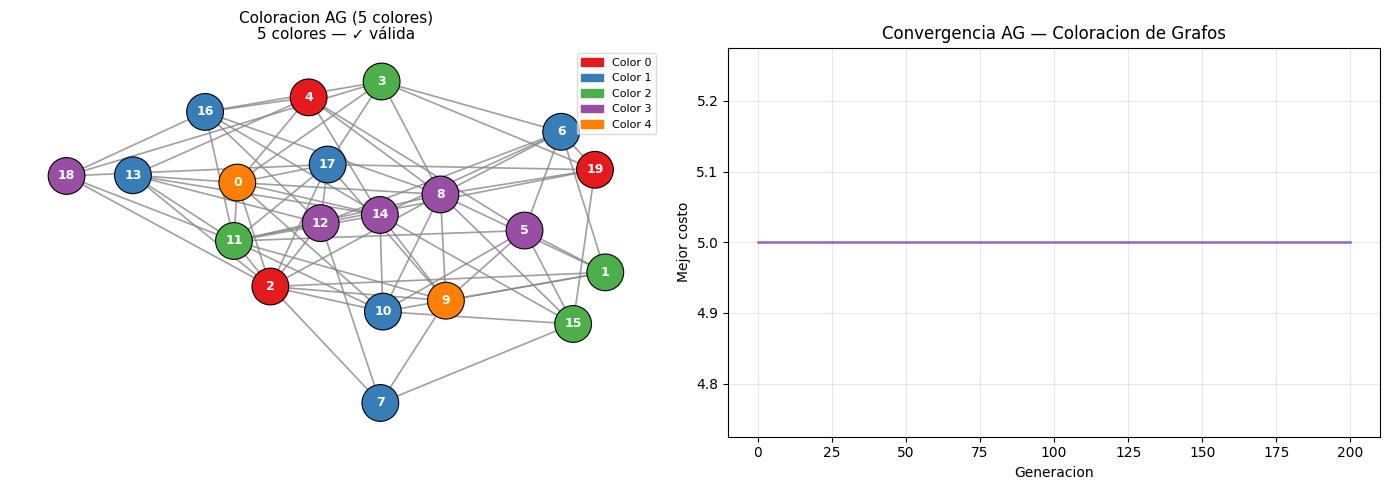

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
common.plot_grafo(G, list(sol_ag),
    f"Coloracion AG ({common.num_colores(list(sol_ag))} colores)", ax=axes[0], pos=pos)
axes[1].plot(hist_ag, color="tab:purple", lw=1.8)
axes[1].set_title("Convergencia AG — Coloracion de Grafos")
axes[1].set_xlabel("Generacion"); axes[1].set_ylabel("Mejor costo")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Sensibilidad a parámetros


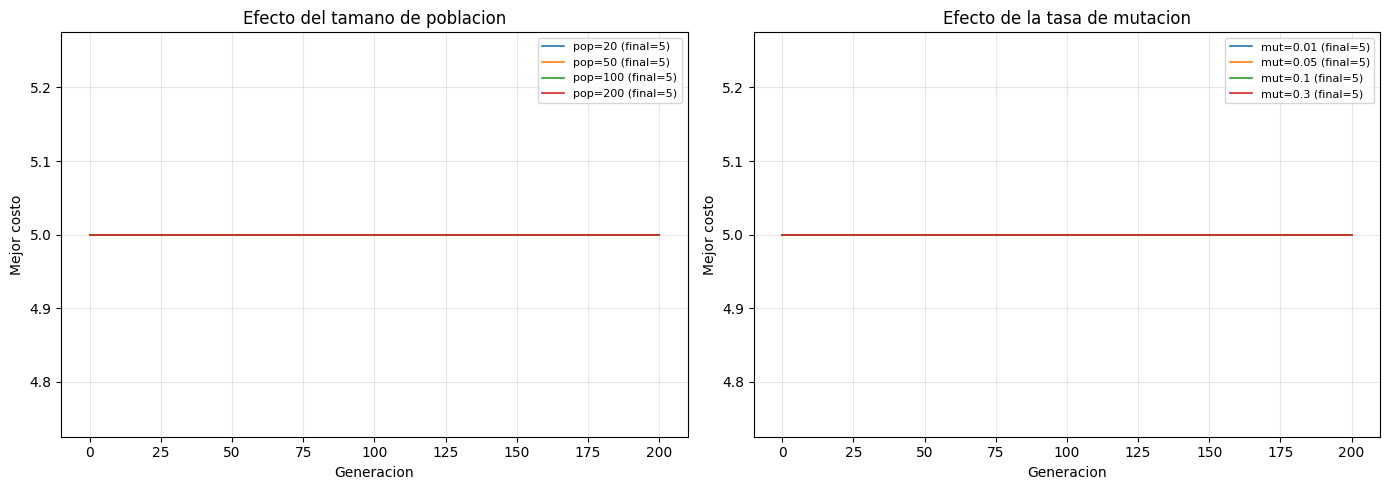

Mutacion baja -> convergencia prematura; mutacion alta -> busqueda aleatoria.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tam in [20, 50, 100, 200]:
    _, c, h = algoritmo_genetico(G, K=K_MAX, tam_pop=tam, n_gen=200, seed=7)
    axes[0].plot(h, label=f"pop={tam} (final={c})", lw=1.2)
axes[0].set_title("Efecto del tamano de poblacion")
axes[0].set_xlabel("Generacion"); axes[0].set_ylabel("Mejor costo")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for tasa in [0.01, 0.05, 0.1, 0.3]:
    _, c, h = algoritmo_genetico(G, K=K_MAX, tasa_mut=tasa, n_gen=200, seed=7)
    axes[1].plot(h, label=f"mut={tasa} (final={c})", lw=1.2)
axes[1].set_title("Efecto de la tasa de mutacion")
axes[1].set_xlabel("Generacion"); axes[1].set_ylabel("Mejor costo")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("Mutacion baja -> convergencia prematura; mutacion alta -> busqueda aleatoria.")


## Ejemplo 2 — Función de Ackley (optimización continua)

El **mismo motor** ahora optimiza una función continua multimodal — ilustra la
generalidad del AG. Solo cambian la codificación y los operadores.

### La función de Ackley
Clásico benchmark con **muchos óptimos locales** y único óptimo global en el origen:

$$f(\mathbf{x}) = -20\exp\!\left(-0.2\sqrt{\tfrac{1}{d}\textstyle\sum x_i^2}\right)
 - \exp\!\left(\tfrac{1}{d}\textstyle\sum \cos(2\pi x_i)\right) + 20 + e$$

- $d=2$, $x_i \in [-5, 5]$; $f(\mathbf{0}) = 0$ (mínimo global).

### Operadores para espacio continuo
- **Cruce BLX-$\alpha$:** gen del hijo = uniforme en $[\min(p_i, p_j) - \alpha d, \max + \alpha d]$.
  Permite explorar más allá de los padres.
- **Mutación Gaussiana:** añadir $\mathcal{N}(0, \sigma)$ a cada gen con probabilidad `tasa`.


In [5]:
LOW, HIGH = -5.0, 5.0

def ackley(x):
    d = len(x)
    return (-20.0 * np.exp(-0.2 * np.sqrt(np.sum(x**2)/d))
            - np.exp(np.sum(np.cos(2*np.pi*x))/d) + 20.0 + np.e)

def cruce_blx(p1, p2, alpha=0.5):
    lo, hi = np.minimum(p1, p2), np.maximum(p1, p2)
    span = hi - lo
    h1 = np.random.uniform(lo - alpha*span, hi + alpha*span)
    h2 = np.random.uniform(lo - alpha*span, hi + alpha*span)
    return np.clip(h1, LOW, HIGH), np.clip(h2, LOW, HIGH)

def mutacion_gaussiana(x, sigma=0.3, tasa=0.3):
    x = x.copy()
    mask = np.random.random(len(x)) < tasa
    x[mask] += np.random.normal(0, sigma, size=mask.sum())
    return np.clip(x, LOW, HIGH)

def ag_continuo(n_gen=150, tam_pop=60, seed=0):
    np.random.seed(seed)
    d = 2
    pop = [np.random.uniform(LOW, HIGH, d) for _ in range(tam_pop)]
    fit_fn = lambda x: -ackley(x)
    fits = [fit_fn(x) for x in pop]
    mejor = pop[np.argmax(fits)].copy(); mejor_fit = max(fits); hist = [-mejor_fit]

    for _ in range(n_gen):
        orden = np.argsort(fits)[::-1]
        nueva = [pop[orden[i]].copy() for i in range(2)]
        while len(nueva) < tam_pop:
            p1 = seleccion_torneo(pop, fits, k=3)
            p2 = seleccion_torneo(pop, fits, k=3)
            h1, h2 = cruce_blx(p1, p2)
            nueva.append(mutacion_gaussiana(h1))
            if len(nueva) < tam_pop:
                nueva.append(mutacion_gaussiana(h2))
        pop = nueva; fits = [fit_fn(x) for x in pop]
        idx = np.argmax(fits)
        if fits[idx] > mejor_fit: mejor_fit = fits[idx]; mejor = pop[idx].copy()
        hist.append(-mejor_fit)
    return mejor, -mejor_fit, hist

mejor_x, mejor_val, hist_ack = ag_continuo(seed=3)
print(f"AG — Ackley (d=2):")
print(f"  Mejor punto: ({mejor_x[0]:.4f}, {mejor_x[1]:.4f})")
print(f"  f(x) = {mejor_val:.6f}  (optimo global = 0.0 en el origen)")


AG — Ackley (d=2):
  Mejor punto: (-0.0000, 0.0000)
  f(x) = 0.000005  (optimo global = 0.0 en el origen)


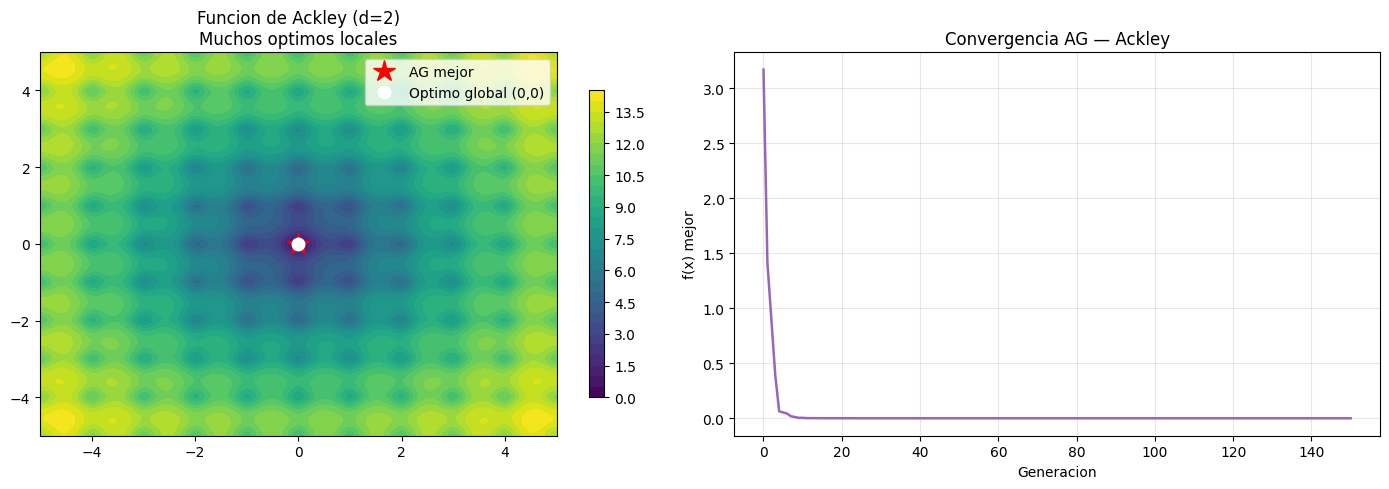

In [6]:
g = np.linspace(LOW, HIGH, 300)
X, Y = np.meshgrid(g, g)
Z = np.vectorize(lambda a,b: ackley(np.array([a,b])))(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cf = axes[0].contourf(X, Y, Z, levels=30, cmap="viridis")
axes[0].plot(mejor_x[0], mejor_x[1], "r*", markersize=16, label="AG mejor")
axes[0].plot(0, 0, "wo", markersize=9, label="Optimo global (0,0)")
axes[0].set_title("Funcion de Ackley (d=2)\nMuchos optimos locales")
axes[0].legend(); plt.colorbar(cf, ax=axes[0], shrink=0.8)
axes[1].plot(hist_ack, color="tab:purple", lw=1.8)
axes[1].set_title("Convergencia AG — Ackley")
axes[1].set_xlabel("Generacion"); axes[1].set_ylabel("f(x) mejor")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Parámetros, complejidad y preguntas frecuentes

**Complejidad:** $O(\text{pop} \times n_{\text{gen}} \times \text{costo fitness})$.

**¿Qué es la convergencia prematura?**
Toda la población queda dominada por pocos individuos; el cruce entre clones no
produce nada nuevo y la búsqueda se estanca. Se evita con: más mutación, mayor
población, torneo con $k$ pequeño, reinicio de subpoblaciones.

**¿Por qué el cruce es útil?**
Combina "bloques de construcción" de dos padres buenos para crear un hijo con
ambos. Funciona cuando el fitness es separable y los bloques son compactos.

**¿Diferencia entre cruce uniforme y cruce de un punto?**
- **Un punto:** cortar en una posición; preserva correlación espacial entre genes adyacentes.
- **Uniforme:** cada gen independientemente; más disruptivo, sin supuestos espaciales.

**¿Cuándo preferir AG sobre SA o Tabú?**
- AG: cuando combinar soluciones tiene sentido semántico; paralelizable fácilmente.
- SA: cuando el vecindario es sencillo y la memoria es limitada.
- Tabú: cuando el vecindario tiene estructura aprovechable y es evaluable rápido.

## Ejercicios
1. Reemplaza cruce uniforme con **cruce de 2 puntos** y compara.
2. Implementa **selección por ruleta** (roulette-wheel) y compara con torneo.
3. Agrega un **operador de reparación** post-cruce en coloración: renombra colores para reducir su cantidad.
4. Escala Ackley a $d=5$ y ajusta parámetros para lograr $f(x) < 1$.

## Referencias
- Holland, *Adaptation in Natural and Artificial Systems* (1975).
- Goldberg, *Genetic Algorithms in Search, Optimization, and Machine Learning* (1989).
- Eiben & Smith, *Introduction to Evolutionary Computing* (2015).
